In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv")
print(df.shape)
df.head()
# Convert timestamp
df["ts"] = pd.to_datetime(df["ts"], format="mixed", utc=True)
# Sort chronologically
df = df.sort_values("ts").reset_index(drop=True)
print(df[["ts"]].head())
# select server
SERVER_ID = 3
server_df = (
    df[df["host_id"] == SERVER_ID]
    .copy()
    .sort_values("ts")
    .reset_index(drop=True)
)
print("Rows:", len(server_df))
print(server_df[["host_id","hostName"]].drop_duplicates())

(74252, 31)
                                ts
0 2026-04-02 12:44:09.710000+00:00
1 2026-04-02 12:44:09.710000+00:00
2 2026-04-02 12:44:09.710000+00:00
3 2026-04-02 12:46:02.041000+00:00
4 2026-04-02 12:46:02.041000+00:00
Rows: 24751
   host_id    hostName
0        3  10.10.10.2


In [3]:
# define parameters
# ======================================
# Forecast Configuration
# ======================================
LOOKBACK = 432          # Previous 36 Hours
FORECAST_HORIZON = 36   # Next 3 Hours
print(f"History Used : {LOOKBACK} timestamps ({LOOKBACK*5/60:.0f} Hours)")
print(f"Prediction   : {FORECAST_HORIZON} timestamps ({FORECAST_HORIZON*5/60:.0f} Hours)")

History Used : 432 timestamps (36 Hours)
Prediction   : 36 timestamps (3 Hours)


In [4]:
# ======================================
# Create CPU Lag Features
# Previous 36 Hours (432 timestamps)
# ======================================
for lag in range(1, LOOKBACK + 1):
    server_df[f"cpu_lag_{lag}"] = server_df["cpu_usage_pct"].shift(lag)
print(f"Created {LOOKBACK} lag features.")
# ======================================
# Create Future Target Columns
# Next 3 Hours (36 timestamps)
# ======================================
for step in range(1, FORECAST_HORIZON + 1):
    server_df[f"target_t+{step}"] = server_df["cpu_usage_pct"].shift(-step)
print(f"Created {FORECAST_HORIZON} target columns.")
# ======================================
# Remove Missing Values
# ======================================
original_rows = len(server_df)
server_df = server_df.dropna().reset_index(drop=True)
print(f"Original Rows : {original_rows}")
print(f"Remaining Rows: {len(server_df)}")

Created 432 lag features.
Created 36 target columns.
Original Rows : 24751
Remaining Rows: 24283


In [5]:
# ======================================
# Define Feature Columns
# ======================================
lag_features = [f"cpu_lag_{i}" for i in range(1, LOOKBACK + 1)]
additional_features = [
    "memory_usage_pct",
    "power_kw",
    "cpu_temp_c",
    "inlet_temp_c",
    "cpu_change",
    "cpu_roll_mean_3",
    "cpu_volatility",
    "resource_stress_index",
    "hour_of_day",
    "day_of_week",
    "is_weekend"
]
feature_columns = lag_features + additional_features
target_columns = [
    f"target_t+{i}"
    for i in range(1, FORECAST_HORIZON + 1)
]
print("Number of Input Features :", len(feature_columns))
print("Number of Output Targets :", len(target_columns))

Number of Input Features : 443
Number of Output Targets : 36


In [6]:
# ======================================
# Create Feature Matrix
# ======================================
X = server_df[feature_columns]
Y = server_df[target_columns]
print("X Shape :", X.shape)
print("Y Shape :", Y.shape)

X Shape : (24283, 443)
Y Shape : (24283, 36)


In [7]:
# ======================================
# Train-Test Split
# ======================================
split_index = int(len(server_df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
Y_train = Y.iloc[:split_index]
Y_test = Y.iloc[split_index:]
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
# ======================================
# Check Missing Values
# ======================================
print("Missing values in X_train :", X_train.isnull().sum().sum())
print("Missing values in X_test  :", X_test.isnull().sum().sum())
print("Missing values in Y_train :", Y_train.isnull().sum().sum())
print("Missing values in Y_test  :", Y_test.isnull().sum().sum())

Training Samples : 19426
Testing Samples  : 4857
Missing values in X_train : 0
Missing values in X_test  : 0
Missing values in Y_train : 0
Missing values in Y_test  : 0


In [8]:
# ======================================
# Train Multi-Output XGBoost Model
# ======================================
model = MultiOutputRegressor(
    XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)
print("Training model...")
model.fit(X_train, Y_train)
print("Training Complete!")

Training model...
Training Complete!


In [9]:
import joblib
import os
os.makedirs("models", exist_ok=True)
joblib.dump(model, f"models/xgb_3hour_model_server{SERVER_ID}.pkl")
print(f"✓ Forecast model for Server {SERVER_ID} saved successfully.")

✓ Forecast model for Server 3 saved successfully.


In [10]:
# predict next 3 hours
# ======================================
# Predict
# ======================================
Y_pred = model.predict(X_test)
print("Prediction Shape :", Y_pred.shape)

Prediction Shape : (4857, 36)


In [11]:
# convert predictions to dataframe
# ======================================
# Convert Predictions
# ======================================
pred_df = pd.DataFrame(
    Y_pred,
    columns=target_columns,
    index=Y_test.index
)
pred_df.head()

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+27,target_t+28,target_t+29,target_t+30,target_t+31,target_t+32,target_t+33,target_t+34,target_t+35,target_t+36
19426,27.961870,27.844824,28.261763,27.821014,28.431953,27.764273,27.907707,27.583868,28.129566,27.925873,...,28.311563,27.775019,27.782881,28.022230,27.715755,27.721186,28.329035,27.920187,28.105206,27.932138
19427,27.789244,27.852280,28.151981,28.262714,27.518492,28.130297,27.795343,27.797291,27.950153,27.782475,...,28.064140,27.782469,28.204166,27.805410,27.799726,28.142265,27.940346,28.254686,27.740051,28.367767
19428,28.082476,28.285252,28.040449,27.522232,28.007437,27.940037,28.304485,27.975044,27.882330,27.857082,...,27.771284,27.876661,27.934332,28.128986,28.357861,27.998211,28.000584,27.830957,28.089111,27.844805
19429,28.004787,28.341805,27.662447,28.121782,27.767008,28.124546,28.136559,27.968279,27.889166,28.024050,...,27.961313,27.850756,28.105995,28.117041,28.119677,28.311928,27.869486,27.975805,27.830751,27.766510
19430,28.435896,27.579271,28.256710,27.826157,27.955444,28.001566,28.257088,27.849350,27.854717,28.246801,...,27.613062,28.351618,28.145512,28.066484,28.228249,27.996002,28.212914,28.056381,28.051357,28.157427


In [12]:
# overall performance metrics
# ======================================
# Overall Metrics
# ======================================
actual = Y_test.values.flatten()
predicted = Y_pred.flatten()
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)
print("="*50)
print("Overall Test Performance")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Overall Test Performance
MAE  : 0.8629
RMSE : 1.0912
R²   : 0.4472


In [13]:
# ======================================
# Horizon-wise Performance
# ======================================
metrics = []
for i in range(FORECAST_HORIZON):
    horizon = (i + 1) * 5
    actual = Y_test.iloc[:, i]
    pred = Y_pred[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)

    metrics.append([horizon, mae, rmse, r2])
metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Minutes Ahead",
        "MAE",
        "RMSE",
        "R²"
    ]
)
metrics_df

,Minutes Ahead,MAE,RMSE,R²
0,5,0.818576,1.016715,0.520274
1,10,0.807175,0.991040,0.544087
2,15,0.810931,1.001220,0.534668
3,20,0.844695,1.055361,0.482975
4,25,0.812963,1.003337,0.532623
5,30,0.839659,1.049092,0.489068
6,35,0.815759,1.013032,0.523474
7,40,0.826783,1.026332,0.510873
8,45,0.827045,1.028986,0.508343
9,50,0.825298,1.034346,0.503209


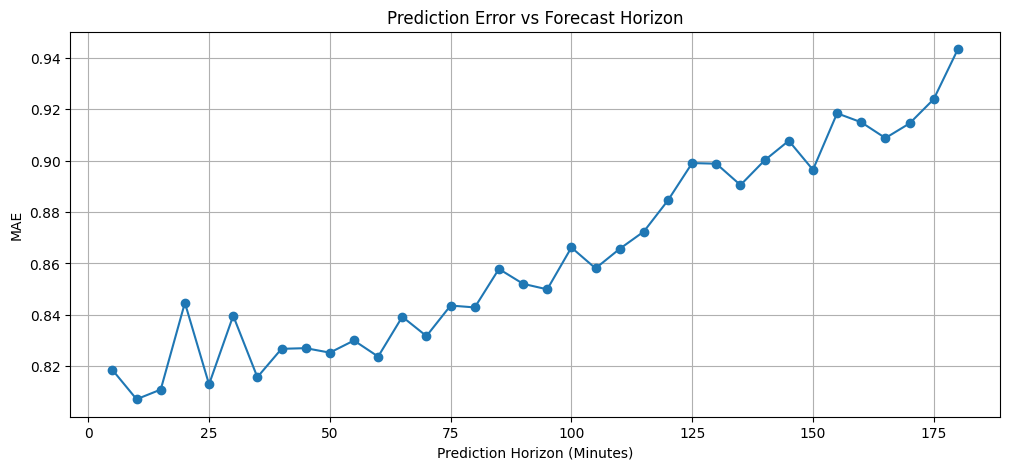

In [14]:
# Average Error vs Prediction Horizon
# ======================================
# Forecast Horizon Performance
# ======================================
plt.figure(figsize=(12,5))
plt.plot(
    metrics_df["Minutes Ahead"],
    metrics_df["MAE"],
    marker="o"
)
plt.grid(True)
plt.xlabel("Prediction Horizon (Minutes)")
plt.ylabel("MAE")
plt.title("Prediction Error vs Forecast Horizon")
plt.show()

In [15]:
# ======================================
# Create Results DataFrame
# ======================================
results_df = pd.DataFrame({
    "Timestamp": server_df.iloc[split_index:].reset_index(drop=True)["ts"]
})
# Add Actual values
for i in range(FORECAST_HORIZON):
    results_df[f"Actual_t+{i+1}"] = Y_test.iloc[:, i].values
# Add Predicted values
for i in range(FORECAST_HORIZON):
    results_df[f"Predicted_t+{i+1}"] = Y_pred[:, i]
print(results_df.shape)
results_df.head()

(4857, 73)


,Timestamp,Actual_t+1,Actual_t+2,Actual_t+3,Actual_t+4,Actual_t+5,Actual_t+6,Actual_t+7,Actual_t+8,Actual_t+9,...,Predicted_t+27,Predicted_t+28,Predicted_t+29,Predicted_t+30,Predicted_t+31,Predicted_t+32,Predicted_t+33,Predicted_t+34,Predicted_t+35,Predicted_t+36
0,2026-05-25 04:54:20.434000+00:00,27.0,29.0,29.0,27.0,28.0,27.0,29.0,29.0,27.0,...,28.311563,27.775019,27.782881,28.022230,27.715755,27.721186,28.329035,27.920187,28.105206,27.932138
1,2026-05-25 04:59:16.887000+00:00,29.0,29.0,27.0,28.0,27.0,29.0,29.0,27.0,30.0,...,28.064140,27.782469,28.204166,27.805410,27.799726,28.142265,27.940346,28.254686,27.740051,28.367767
2,2026-05-25 05:04:16.944000+00:00,29.0,27.0,28.0,27.0,29.0,29.0,27.0,30.0,29.0,...,27.771284,27.876661,27.934332,28.128986,28.357861,27.998211,28.000584,27.830957,28.089111,27.844805
3,2026-05-25 05:09:19.346000+00:00,27.0,28.0,27.0,29.0,29.0,27.0,30.0,29.0,29.0,...,27.961313,27.850756,28.105995,28.117041,28.119677,28.311928,27.869486,27.975805,27.830751,27.766510
4,2026-05-25 05:14:17.326000+00:00,28.0,27.0,29.0,29.0,27.0,30.0,29.0,29.0,29.0,...,27.613062,28.351618,28.145512,28.066484,28.228249,27.996002,28.212914,28.056381,28.051357,28.157427


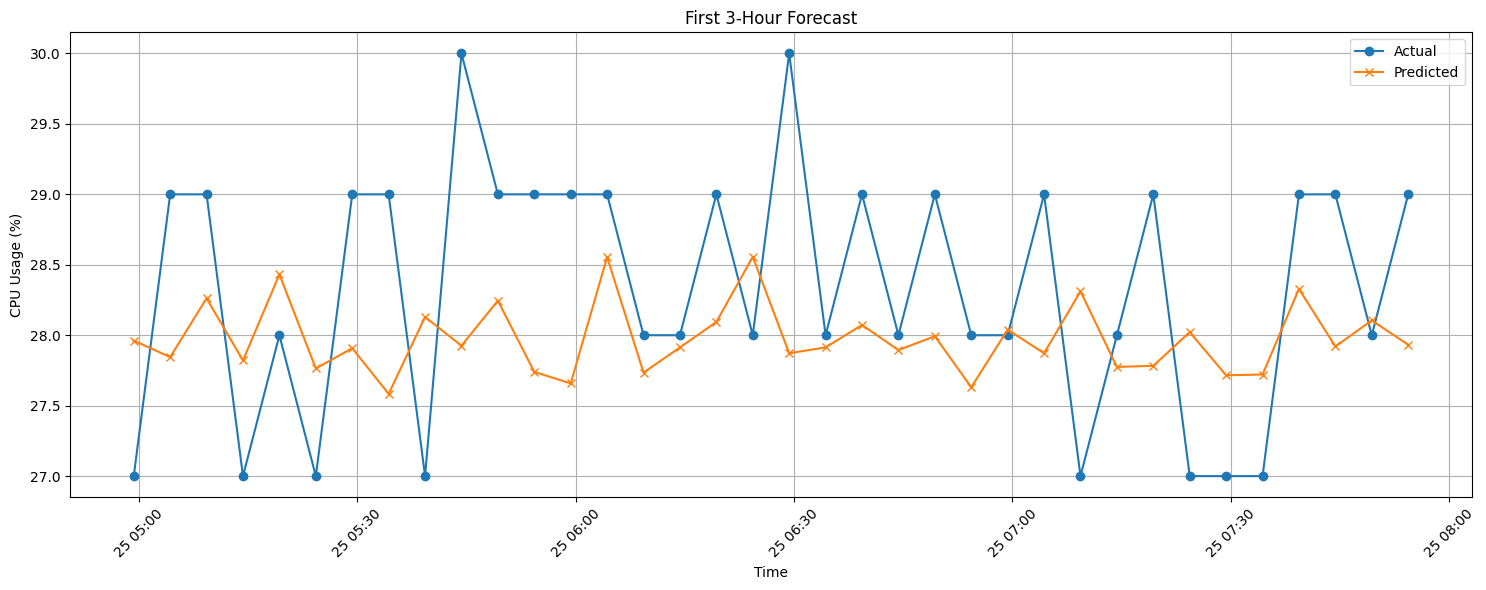

In [16]:
# ======================================
# First 3-Hour Forecast
# ======================================
forecast_times = pd.date_range(
    start=results_df.loc[0, "Timestamp"] + pd.Timedelta(minutes=5),
    periods=FORECAST_HORIZON,
    freq="5min"
)
plt.figure(figsize=(15,6))
plt.plot(
    forecast_times,
    results_df.loc[0, [f"Actual_t+{i}" for i in range(1, FORECAST_HORIZON+1)]].values,
    marker="o",
    label="Actual"
)
plt.plot(
    forecast_times,
    results_df.loc[0, [f"Predicted_t+{i}" for i in range(1, FORECAST_HORIZON+1)]].values,
    marker="x",
    label="Predicted"
)
plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.title("First 3-Hour Forecast")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

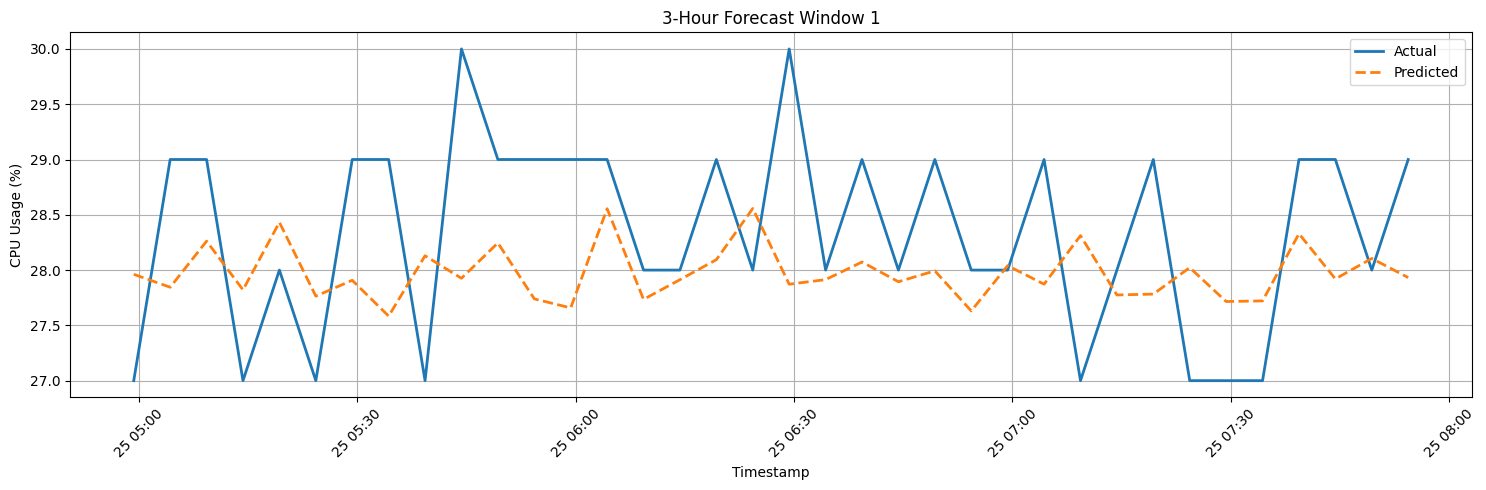

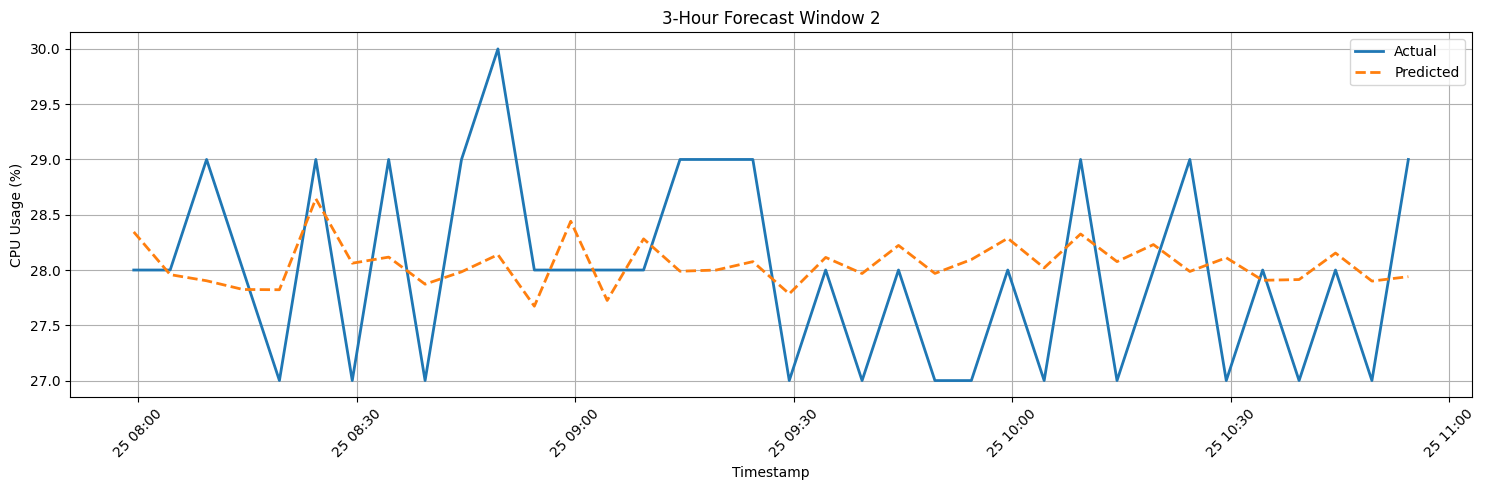

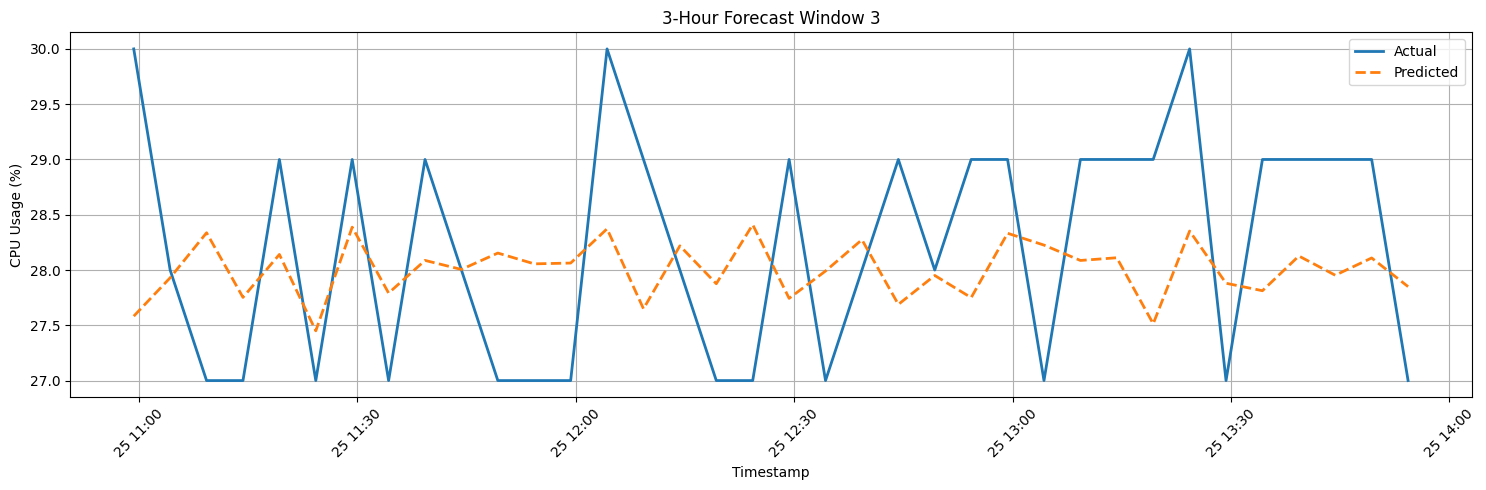

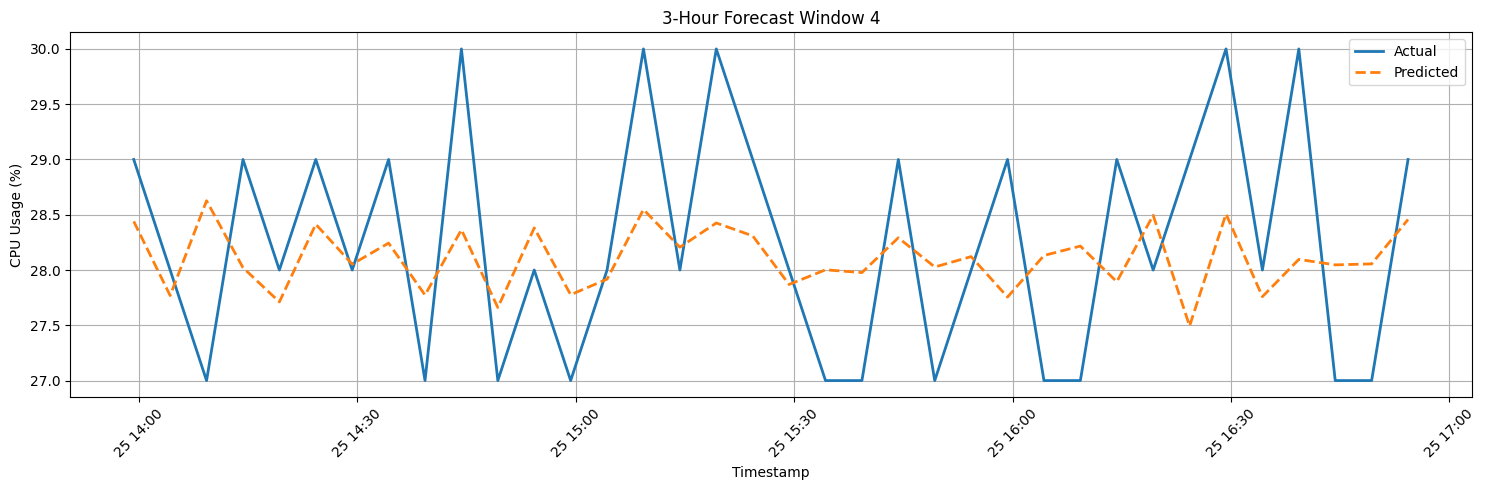

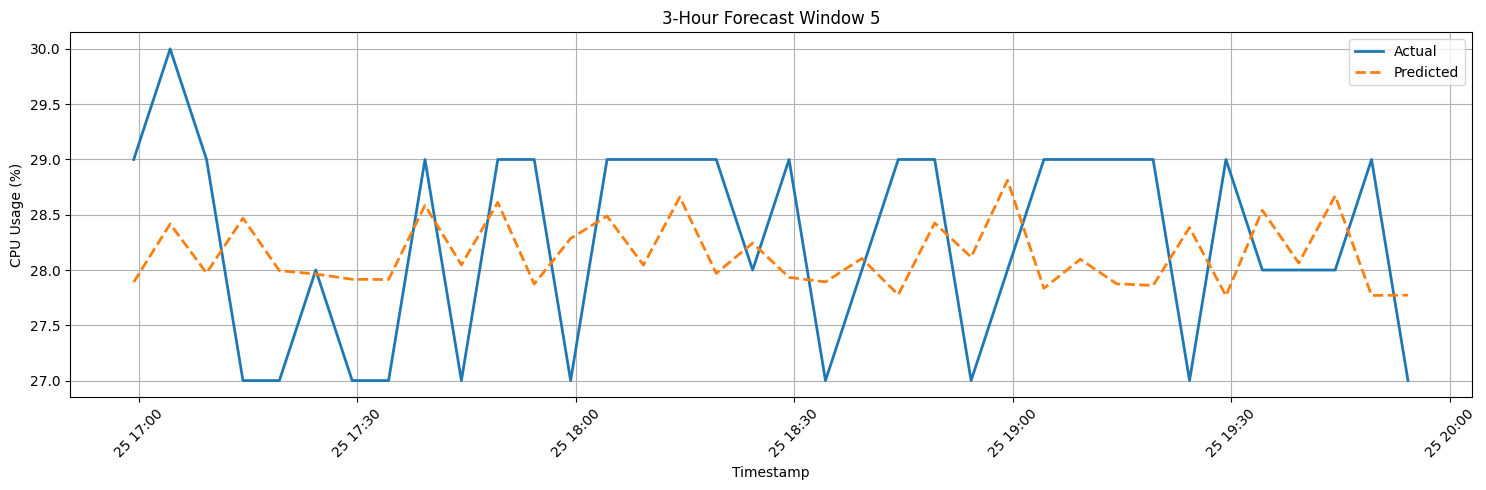

In [17]:
# ======================================
# Compare Consecutive 3-Hour Forecasts
# ======================================
num_windows = 5
for start in range(0, min(len(results_df), num_windows * FORECAST_HORIZON), FORECAST_HORIZON):
    forecast_times = pd.date_range(
        start=results_df.loc[start, "Timestamp"] + pd.Timedelta(minutes=5),
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    plt.figure(figsize=(15,5))
    plt.plot(
        forecast_times,
        results_df.loc[start,
                       [f"Actual_t+{i}" for i in range(1, FORECAST_HORIZON+1)]].values,
        linewidth=2,
        label="Actual"
    )
    plt.plot(
        forecast_times,
        results_df.loc[start,
                       [f"Predicted_t+{i}" for i in range(1, FORECAST_HORIZON+1)]].values,
        "--",
        linewidth=2,
        label="Predicted"
    )
    plt.title(
        f"3-Hour Forecast Window {start//FORECAST_HORIZON + 1}"
    )
    plt.xlabel("Timestamp")
    plt.ylabel("CPU Usage (%)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Plotting: 2026-05-25


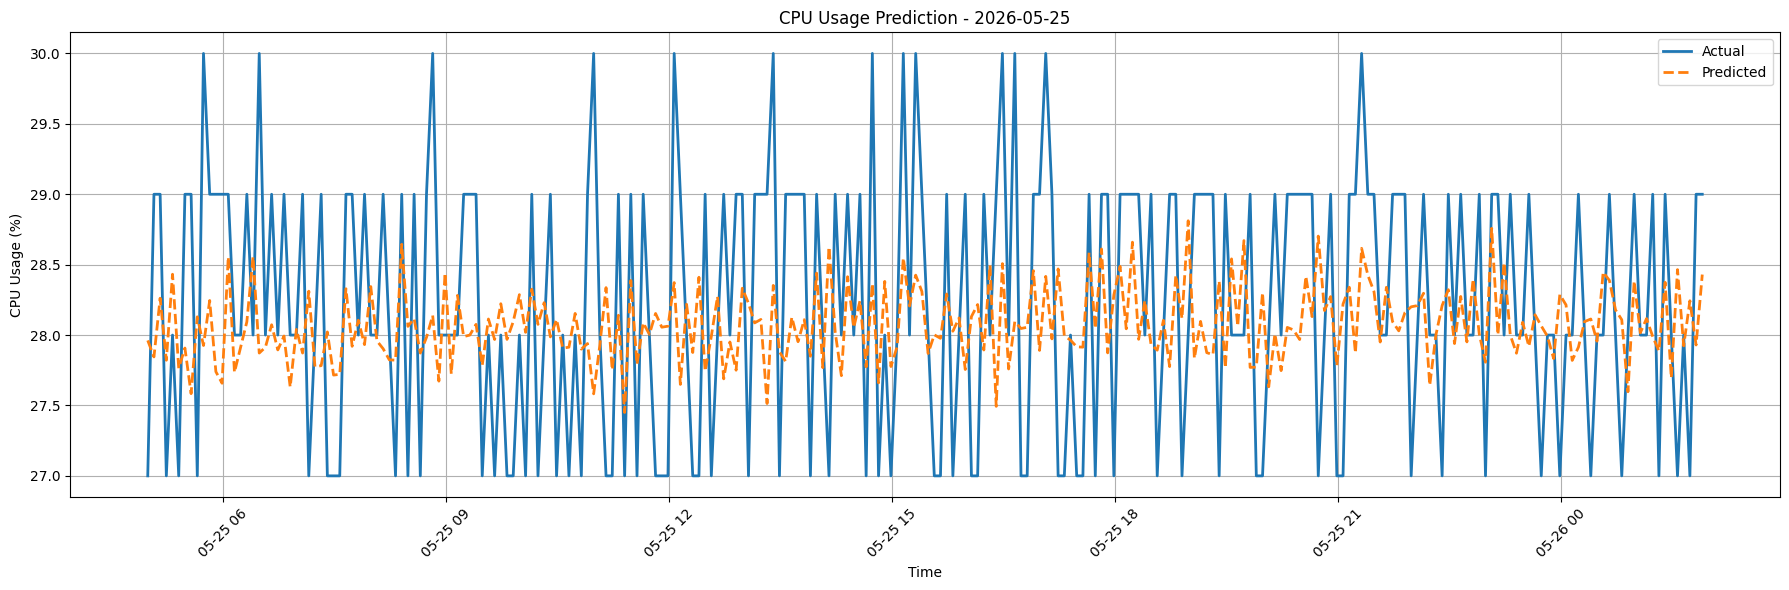

In [18]:
# Actual vs Predicted for the Entire Day (25th May)
# First day in the test set

plot_date = results_df["Timestamp"].dt.date.iloc[0]
print("Plotting:", plot_date)
actual_times = []
actual_values = []
pred_values = []
for idx in range(0, len(results_df), FORECAST_HORIZON):
    start_time = results_df.loc[idx, "Timestamp"]
    forecast_times = pd.date_range(
        start=start_time + pd.Timedelta(minutes=5),
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    if forecast_times[0].date() != plot_date:
        continue
    actual_values.extend(
        results_df.loc[
            idx,
            [f"Actual_t+{i}" for i in range(1, FORECAST_HORIZON+1)]
        ].values
    )
    pred_values.extend(
        results_df.loc[
            idx,
            [f"Predicted_t+{i}" for i in range(1, FORECAST_HORIZON+1)]
        ].values
    )
    actual_times.extend(forecast_times)
plt.figure(figsize=(18,6))
plt.plot(
    actual_times,
    actual_values,
    linewidth=2,
    label="Actual"
)
plt.plot(
    actual_times,
    pred_values,
    "--",
    linewidth=2,
    label="Predicted"
)
plt.title(f"CPU Usage Prediction - {plot_date}")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

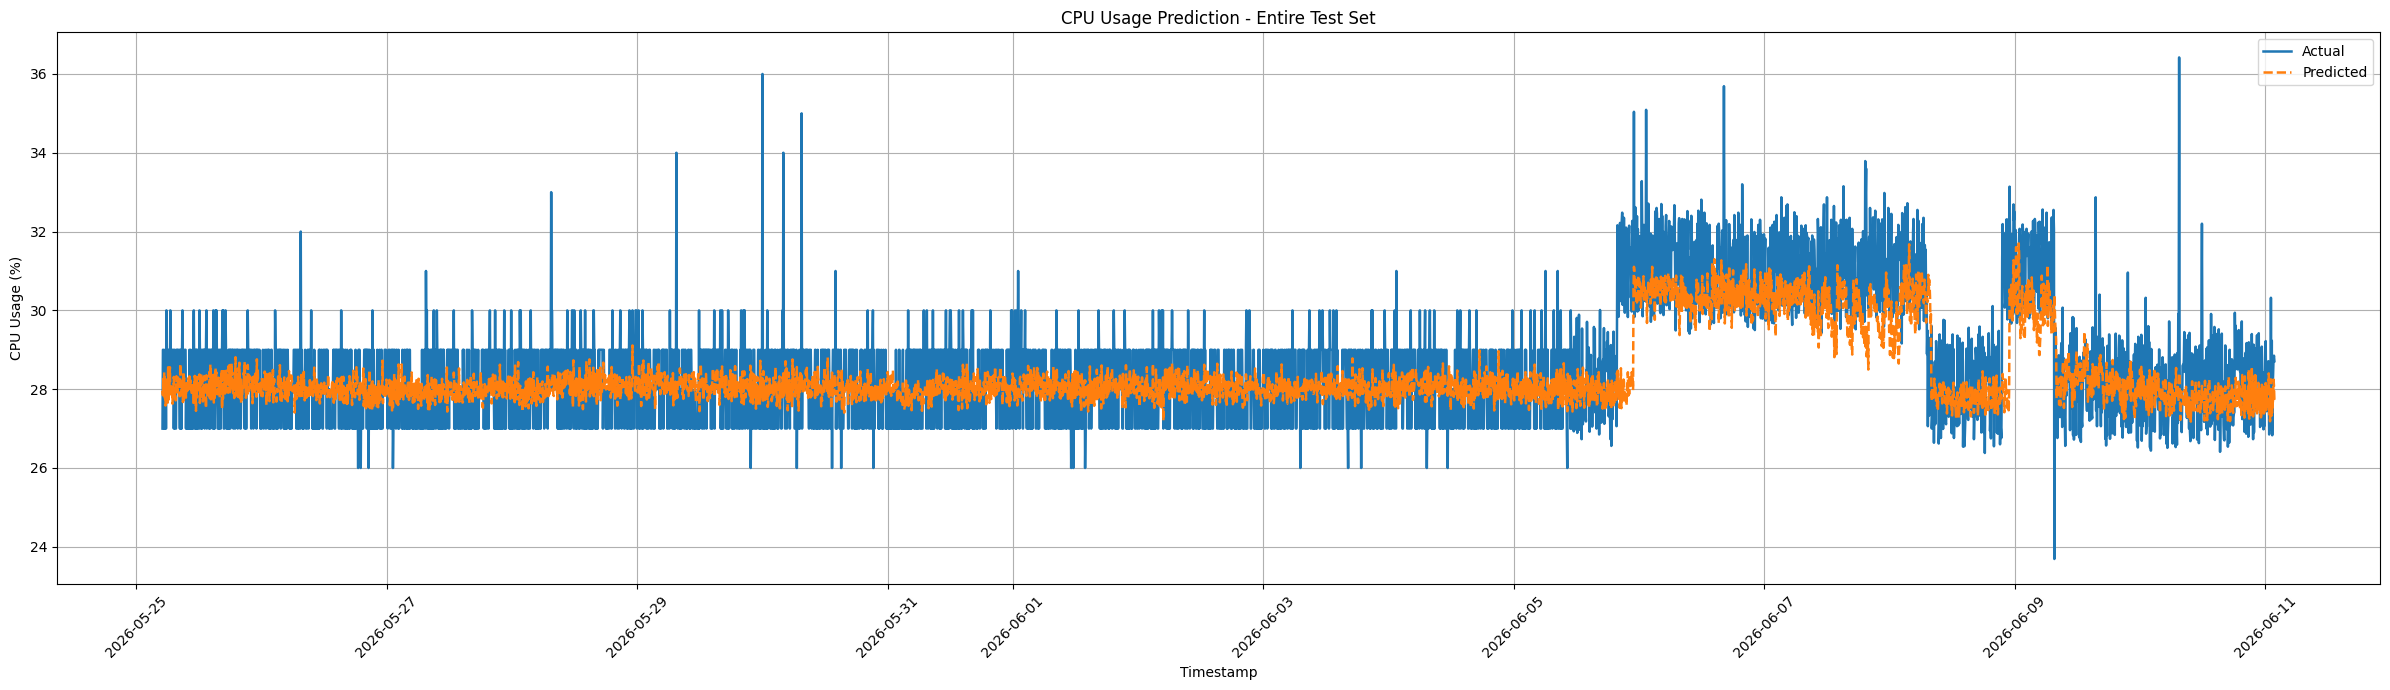

In [19]:
# entire test set plot

all_times = []
all_actual = []
all_pred = []

for idx in range(0, len(results_df), FORECAST_HORIZON):
    start_time = results_df.loc[idx, "Timestamp"]
    forecast_times = pd.date_range(
        start=start_time + pd.Timedelta(minutes=5),
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    all_times.extend(forecast_times)
    all_actual.extend(
        results_df.loc[
            idx,
            [f"Actual_t+{i}" for i in range(1, FORECAST_HORIZON+1)]
        ].values
    )
    all_pred.extend(
        results_df.loc[
            idx,
            [f"Predicted_t+{i}" for i in range(1, FORECAST_HORIZON+1)]
        ].values
    )
plt.figure(figsize=(24,7))
plt.plot(
    all_times,
    all_actual,
    linewidth=1.8,
    label="Actual"
)
plt.plot(
    all_times,
    all_pred,
    "--",
    linewidth=1.8,
    label="Predicted"
)
plt.title("CPU Usage Prediction - Entire Test Set")
plt.xlabel("Timestamp")
plt.ylabel("CPU Usage (%)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

WORKING HOURS FORECAST

In [20]:
# ============================================
# Working Hours Forecast (First Test Day)
# 09:00-12:00
# 12:00-15:00
# 15:00-18:00
# ============================================
# ==========================================
# Create Forecast DataFrame
# One Row = One 3-Hour Forecast
# ==========================================
forecast_rows = []
for idx in range(len(Y_test)):
    # Original forecast start
    actual_start = results_df.loc[idx, "Timestamp"] + pd.Timedelta(minutes=5)
    # Rounded forecast start (for plotting only)
    rounded_start = actual_start.round("5min")
    rounded_end = rounded_start + pd.Timedelta(
        minutes=(FORECAST_HORIZON - 1) * 5
    )
    row = {
        "forecast_start": rounded_start,
        "forecast_end": rounded_end,
        "prediction_day": rounded_start.date(),
        "start_hour": rounded_start.hour,
        "host_id": SERVER_ID,
        "host_name": server_df["hostName"].iloc[0]
    }
    # Actual values
    for i in range(FORECAST_HORIZON):
        row[f"Actual_t+{i+1}"] = Y_test.iloc[idx, i]
    # Predicted values
    for i in range(FORECAST_HORIZON):
        row[f"Predicted_t+{i+1}"] = Y_pred[idx, i]
    forecast_rows.append(row)
forecast_df = pd.DataFrame(forecast_rows)
print(forecast_df.shape)
forecast_df.head()

(4857, 78)


,forecast_start,forecast_end,prediction_day,start_hour,host_id,host_name,Actual_t+1,Actual_t+2,Actual_t+3,Actual_t+4,...,Predicted_t+27,Predicted_t+28,Predicted_t+29,Predicted_t+30,Predicted_t+31,Predicted_t+32,Predicted_t+33,Predicted_t+34,Predicted_t+35,Predicted_t+36
0,2026-05-25 05:00:00+00:00,2026-05-25 07:55:00+00:00,2026-05-25,5,3,10.10.10.2,27.0,29.0,29.0,27.0,...,28.311563,27.775019,27.782881,28.022230,27.715755,27.721186,28.329035,27.920187,28.105206,27.932138
1,2026-05-25 05:05:00+00:00,2026-05-25 08:00:00+00:00,2026-05-25,5,3,10.10.10.2,29.0,29.0,27.0,28.0,...,28.064140,27.782469,28.204166,27.805410,27.799726,28.142265,27.940346,28.254686,27.740051,28.367767
2,2026-05-25 05:10:00+00:00,2026-05-25 08:05:00+00:00,2026-05-25,5,3,10.10.10.2,29.0,27.0,28.0,27.0,...,27.771284,27.876661,27.934332,28.128986,28.357861,27.998211,28.000584,27.830957,28.089111,27.844805
3,2026-05-25 05:15:00+00:00,2026-05-25 08:10:00+00:00,2026-05-25,5,3,10.10.10.2,27.0,28.0,27.0,29.0,...,27.961313,27.850756,28.105995,28.117041,28.119677,28.311928,27.869486,27.975805,27.830751,27.766510
4,2026-05-25 05:20:00+00:00,2026-05-25 08:15:00+00:00,2026-05-25,5,3,10.10.10.2,28.0,27.0,29.0,29.0,...,27.613062,28.351618,28.145512,28.066484,28.228249,27.996002,28.212914,28.056381,28.051357,28.157427


In [21]:
# ==========================================
# Prepare Working Hour Forecasts
# ==========================================
working_blocks = {}
first_day = forecast_df["prediction_day"].iloc[0]
day_data = forecast_df[
    forecast_df["prediction_day"] == first_day
].copy()
for target_hour in [9, 12, 15]:
    target = pd.Timestamp(
        f"{first_day} {target_hour:02d}:00:00",
        tz=forecast_df["forecast_start"].dt.tz
    )
    closest_idx = (
        day_data["forecast_start"] - target
    ).abs().idxmin()
    working_blocks[target_hour] = forecast_df.loc[closest_idx]
    print(
        f"{target_hour:02d}:00 block -> "
        f"{forecast_df.loc[closest_idx,'forecast_start']}"
    )

09:00 block -> 2026-05-25 09:00:00+00:00
12:00 block -> 2026-05-25 12:00:00+00:00
15:00 block -> 2026-05-25 15:00:00+00:00


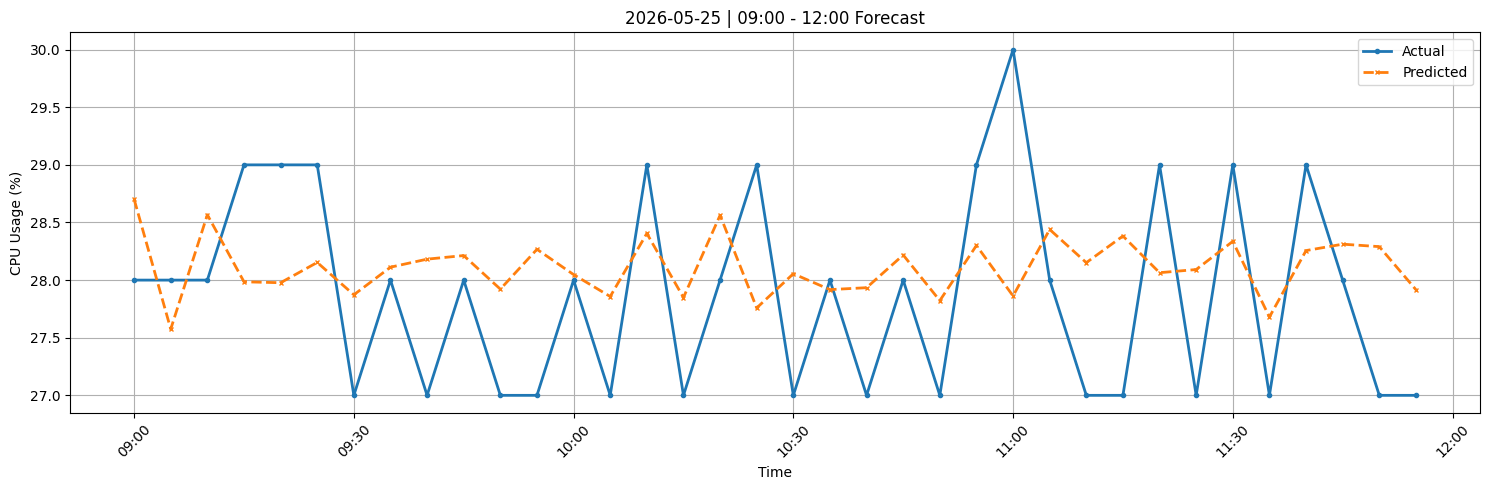

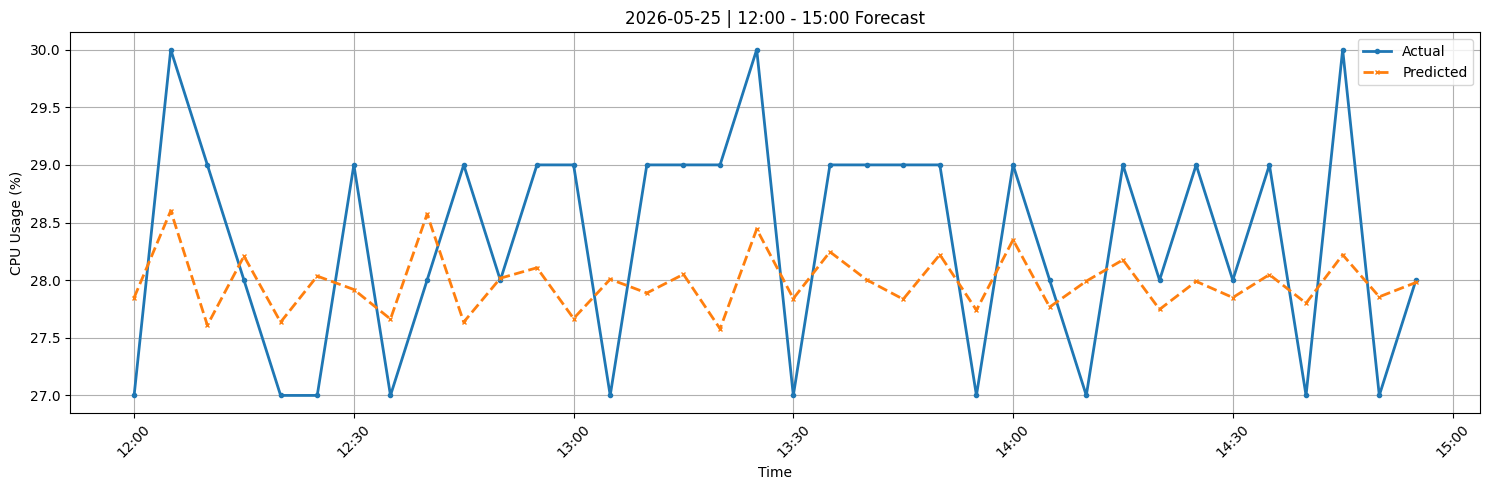

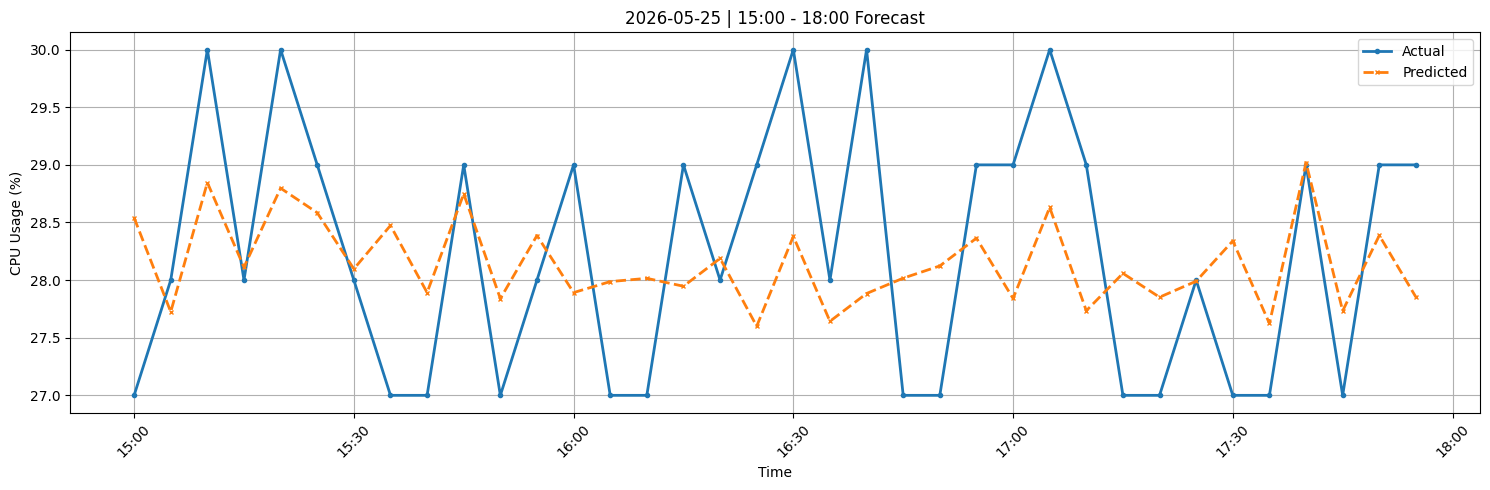

In [22]:
# ==========================================
# Plot All Working Hour Forecasts
# (09-12, 12-15, 15-18)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
for hour in [9, 12, 15]:
    if hour not in working_blocks:
        print(f"No forecast available for {hour:02d}:00")
        continue
    row = working_blocks[hour]
    times = pd.date_range(
        start=row["forecast_start"],
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    actual = np.array([
        row[f"Actual_t+{i}"]
        for i in range(1, FORECAST_HORIZON + 1)
    ])
    predicted = np.array([
        row[f"Predicted_t+{i}"]
        for i in range(1, FORECAST_HORIZON + 1)
    ])
    plt.figure(figsize=(15,5))
    plt.plot(
        times,
        actual,
        linewidth=2,
        marker="o",
        markersize=3,
        label="Actual"
    )
    plt.plot(
        times,
        predicted,
        "--",
        linewidth=2,
        marker="x",
        markersize=3,
        label="Predicted"
    )
    plt.title(
        f"{row['prediction_day']} | "
        f"{hour:02d}:00 - {hour+3:02d}:00 Forecast"
    )
    plt.xlabel("Time")
    plt.ylabel("CPU Usage (%)")
    plt.grid(True)
    plt.legend()
    plt.gca().xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M")
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

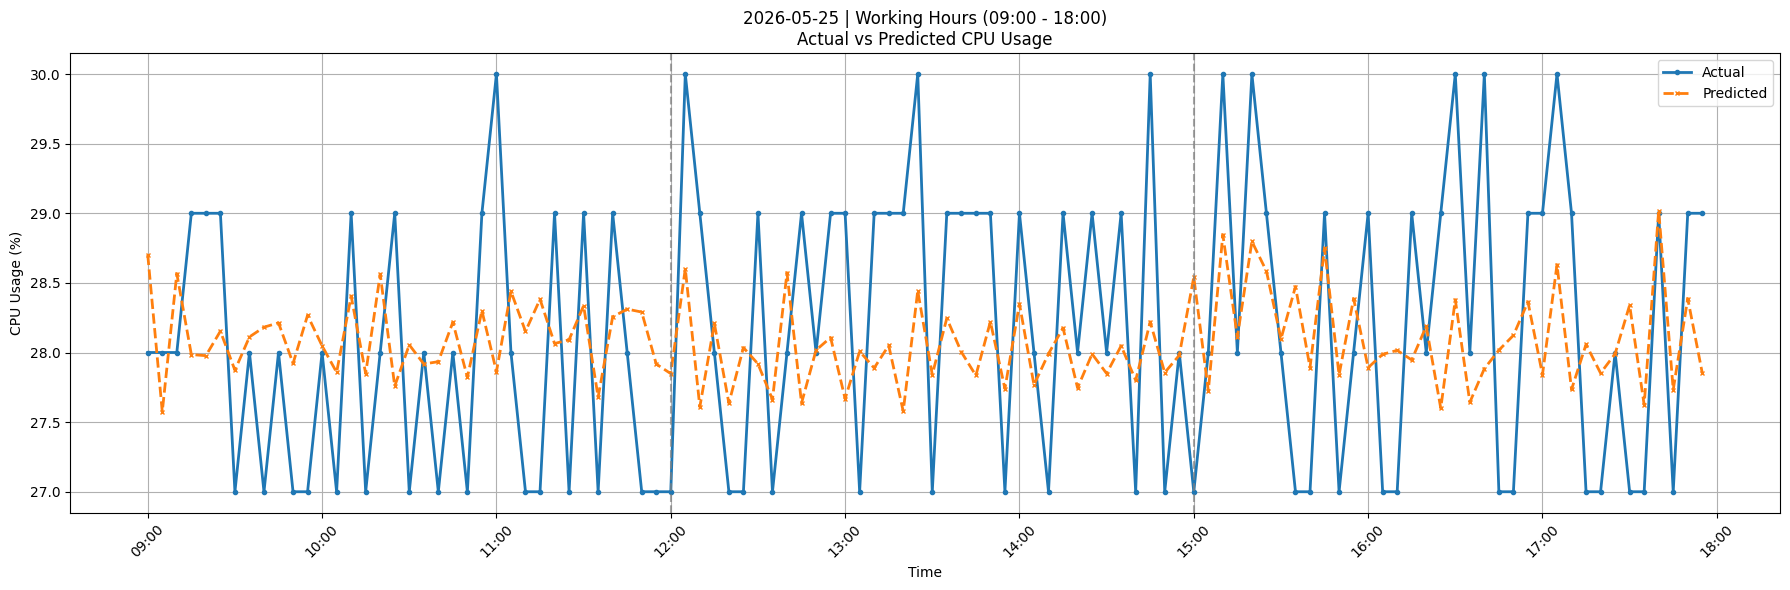

In [23]:
# ==========================================
# Combined Working Hours Plot (09:00 - 18:00)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
all_times = []
all_actual = []
all_predicted = []
# Combine the three working-hour forecasts
for hour in [9, 12, 15]:
    if hour not in working_blocks:
        print(f"No forecast available for {hour}:00")
        continue
    row = working_blocks[hour]
    times = pd.date_range(
        start=row["forecast_start"],
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    actual = [
        row[f"Actual_t+{i}"]
        for i in range(1, FORECAST_HORIZON + 1)
    ]
    predicted = [
        row[f"Predicted_t+{i}"]
        for i in range(1, FORECAST_HORIZON + 1)
    ]
    all_times.extend(times)
    all_actual.extend(actual)
    all_predicted.extend(predicted)
# Convert to arrays
all_actual = np.array(all_actual, dtype=float)
all_predicted = np.array(all_predicted, dtype=float)
# Plot
plt.figure(figsize=(18,6))
plt.plot(
    all_times,
    all_actual,
    linewidth=2,
    marker='o',
    markersize=3,
    label='Actual'
)
plt.plot(
    all_times,
    all_predicted,
    '--',
    linewidth=2,
    marker='x',
    markersize=3,
    label='Predicted'
)
# Draw vertical separators at 12 PM and 3 PM
for split in ["12:00", "15:00"]:
    split_time = pd.Timestamp(
        f"{working_blocks[9]['prediction_day']} {split}",
        tz=working_blocks[9]["forecast_start"].tz
    )
    plt.axvline(split_time, color='gray', linestyle='--', alpha=0.7)
plt.title(
    f"{working_blocks[9]['prediction_day']} | Working Hours (09:00 - 18:00)\n"
    "Actual vs Predicted CPU Usage"
)
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

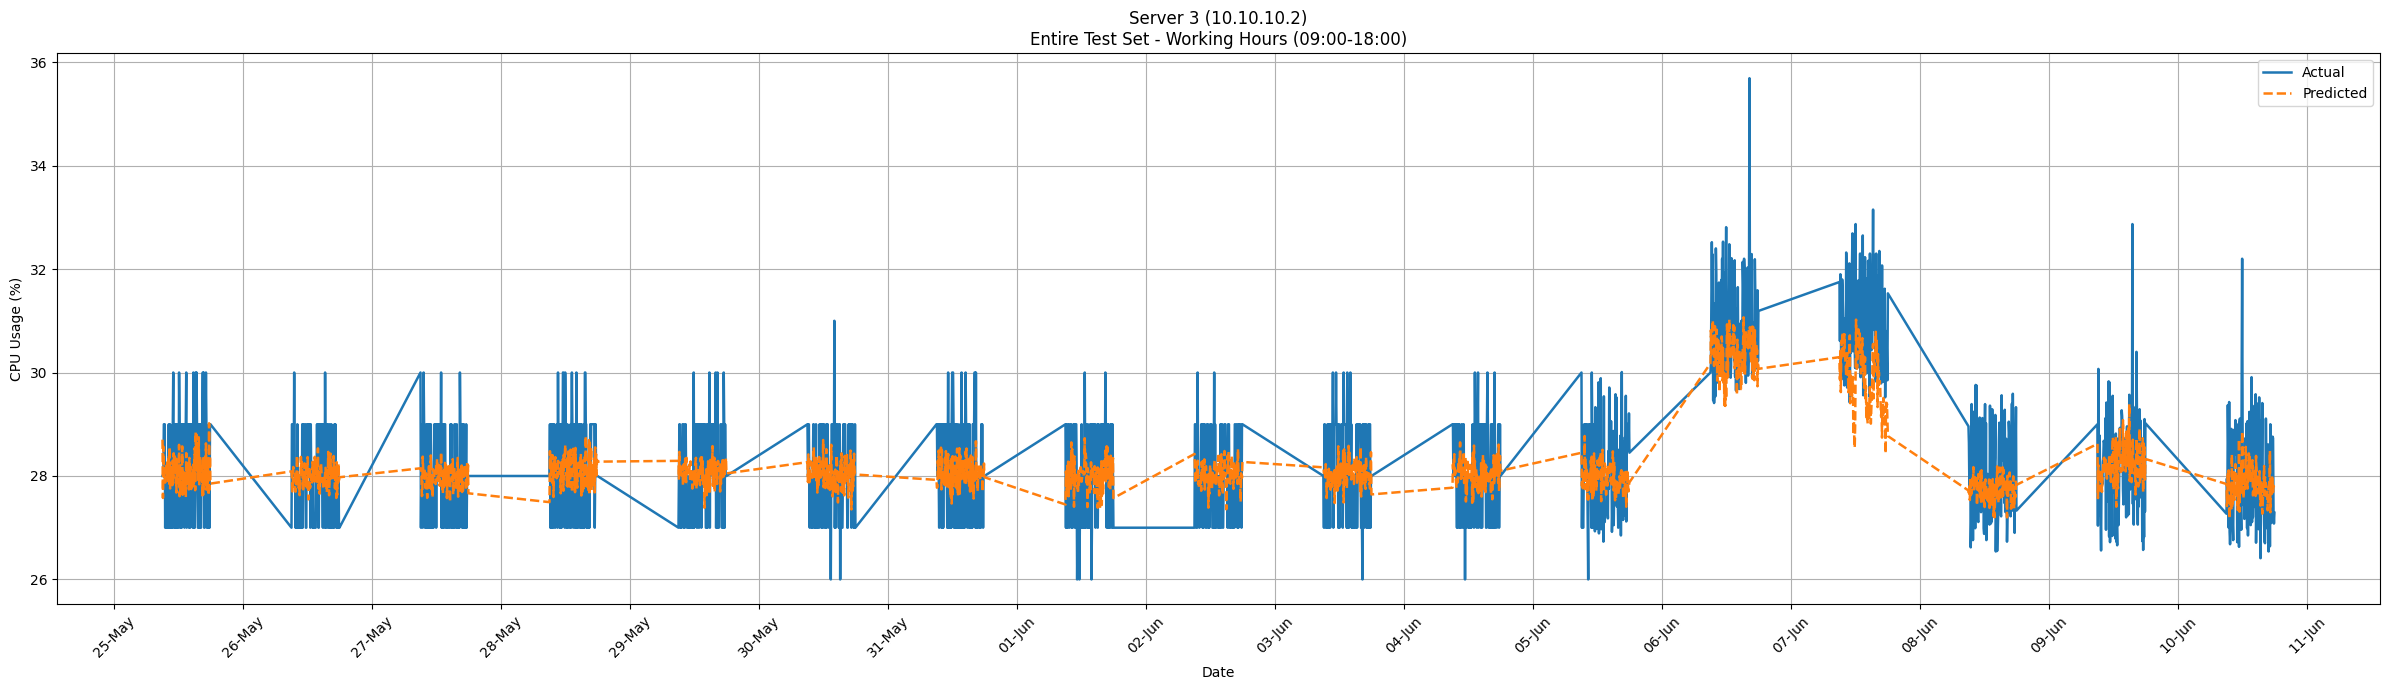

In [24]:
# ==========================================
# Entire Test Set - Working Hours (09:00-18:00)
# One Continuous Plot
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
all_times = []
all_actual = []
all_predicted = []
# All days present in the test set
test_days = sorted(forecast_df["prediction_day"].unique())

for day in test_days:
    day_df = forecast_df[
        forecast_df["prediction_day"] == day
    ].copy()
    if day_df.empty:
        continue
    # Working-hour blocks
    for hour in [9, 12, 15]:
        target_time = pd.Timestamp(
            f"{day} {hour:02d}:00:00",
            tz=forecast_df["forecast_start"].dt.tz
        )
        # Select first forecast AT or AFTER the required hour
        candidates = day_df[
            day_df["forecast_start"] >= target_time
        ]
        if len(candidates) == 0:
            continue
        row = candidates.iloc[0]
        times = pd.date_range(
            start=row["forecast_start"],
            periods=FORECAST_HORIZON,
            freq="5min"
        )
        actual = [
            row[f"Actual_t+{i}"]
            for i in range(1, FORECAST_HORIZON + 1)
        ]
        predicted = [
            row[f"Predicted_t+{i}"]
            for i in range(1, FORECAST_HORIZON + 1)
        ]
        all_times.extend(times)
        all_actual.extend(actual)
        all_predicted.extend(predicted)
# Convert to numpy
all_actual = np.array(all_actual, dtype=float)
all_predicted = np.array(all_predicted, dtype=float)
# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(24,7))
plt.plot(
    all_times,
    all_actual,
    linewidth=1.8,
    label="Actual"
)
plt.plot(
    all_times,
    all_predicted,
    "--",
    linewidth=1.8,
    label="Predicted"
)
plt.title(
    f"Server {SERVER_ID} ({server_df['hostName'].iloc[0]})\n"
    "Entire Test Set - Working Hours (09:00-18:00)"
)
plt.xlabel("Date")
plt.ylabel("CPU Usage (%)")
plt.grid(True)
plt.legend()
# Show one tick per day
plt.gca().xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d-%b")
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

11th JUNE PREDICTION

In [25]:
# ==========================================
# Forecast Next Working Day (11 June)
# 09:00-12:00
# 12:00-15:00
# 15:00-18:00
# ==========================================
future_predictions = {}
# Last available sample
history = server_df.copy()
for block in ["09-12", "12-15", "15-18"]:
    # Last LOOKBACK rows
    recent = history.tail(LOOKBACK)
    # Lag features
    lag_values = recent["cpu_usage_pct"].values[::-1]
    feature_vector = {}
    # cpu_lag_1 = latest observation
    for i in range(LOOKBACK):
        feature_vector[f"cpu_lag_{i+1}"] = lag_values[i]
    # Latest engineered features
    latest = history.iloc[-1]
    for col in additional_features:
        feature_vector[col] = latest[col]
    X_future = pd.DataFrame([feature_vector])
    # Predict next 3 hours
    pred = model.predict(X_future)[0]
    future_predictions[block] = pred

    # Append predictions to history so that
    # next block uses previous predictions
    last_time = history["ts"].iloc[-1]
    new_rows = []
    for value in pred:
        last_time = last_time + pd.Timedelta(minutes=5)
        row = latest.copy()
        row["ts"] = last_time
        row["cpu_usage_pct"] = value
        new_rows.append(row)
    history = pd.concat(
        [history, pd.DataFrame(new_rows)],
        ignore_index=True
    )
print("Prediction Complete.")

Prediction Complete.


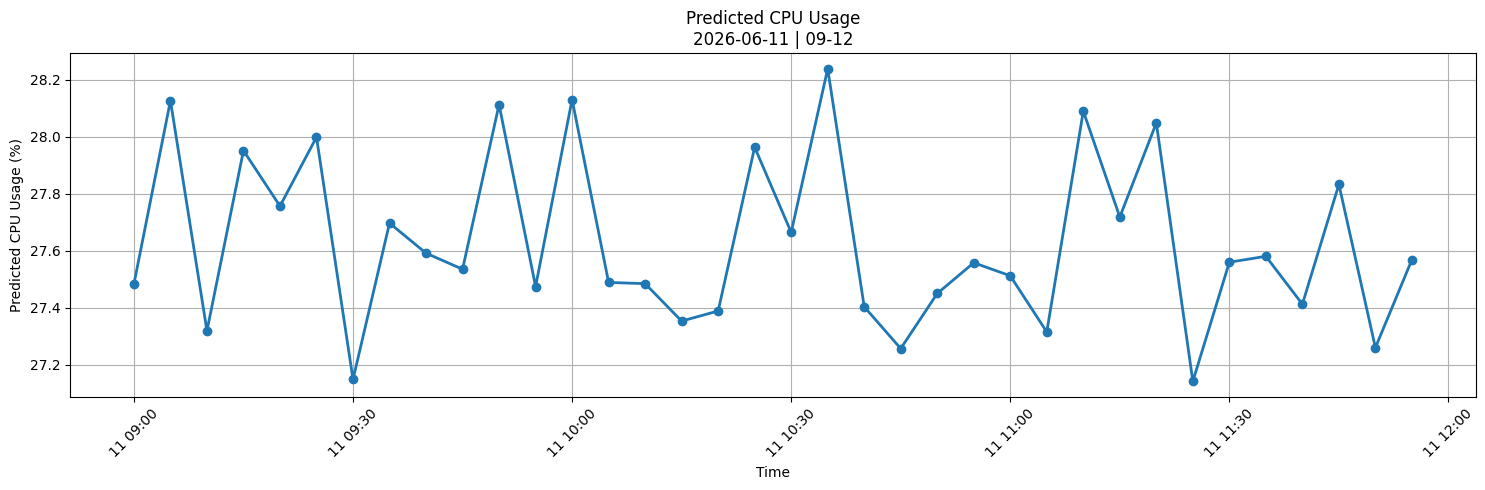

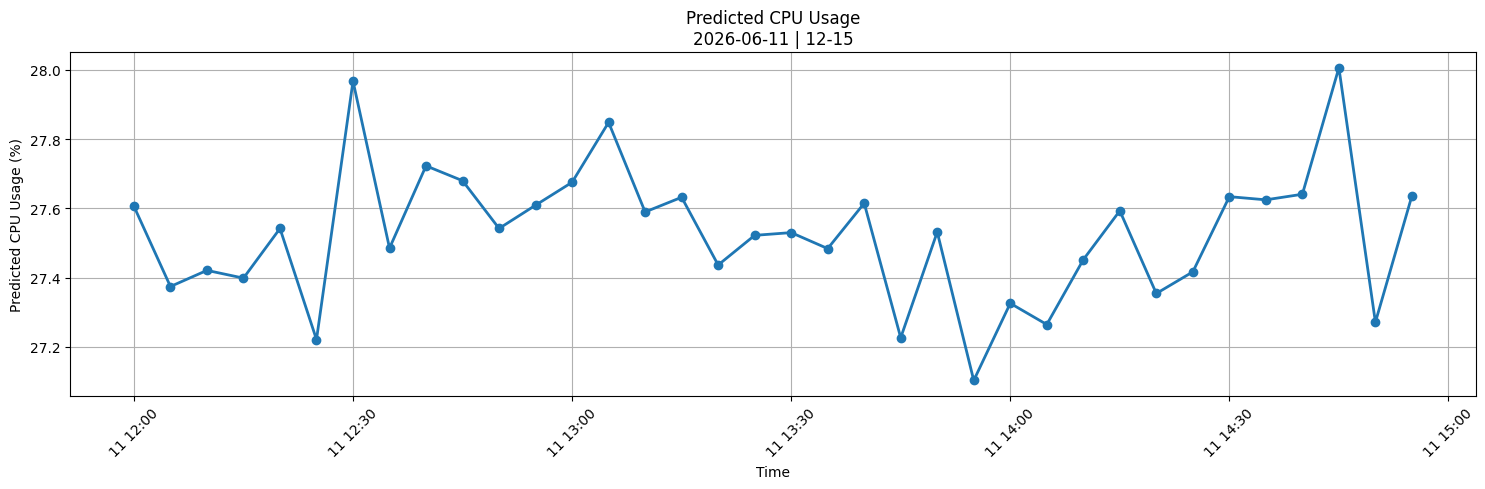

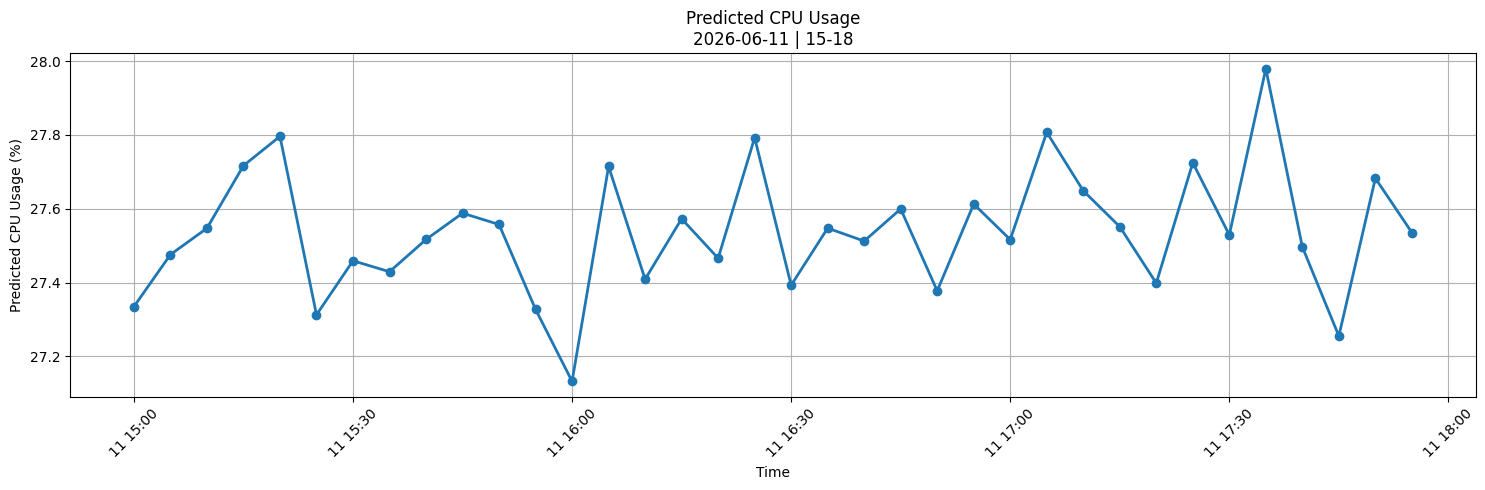

In [26]:
# ==========================================
# Plot Each Working Block
# ==========================================
import matplotlib.pyplot as plt
forecast_date = history["ts"].iloc[-108].date()
start_hours = {
    "09-12":9,
    "12-15":12,
    "15-18":15
}
for block in ["09-12","12-15","15-18"]:
    start = pd.Timestamp(
        f"{forecast_date} {start_hours[block]:02d}:00:00"
    )
    times = pd.date_range(
        start=start,
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    plt.figure(figsize=(15,5))
    plt.plot(
        times,
        future_predictions[block],
        marker='o',
        linewidth=2
    )
    plt.title(
        f"Predicted CPU Usage\n{forecast_date} | {block}"
    )
    plt.xlabel("Time")
    plt.ylabel("Predicted CPU Usage (%)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

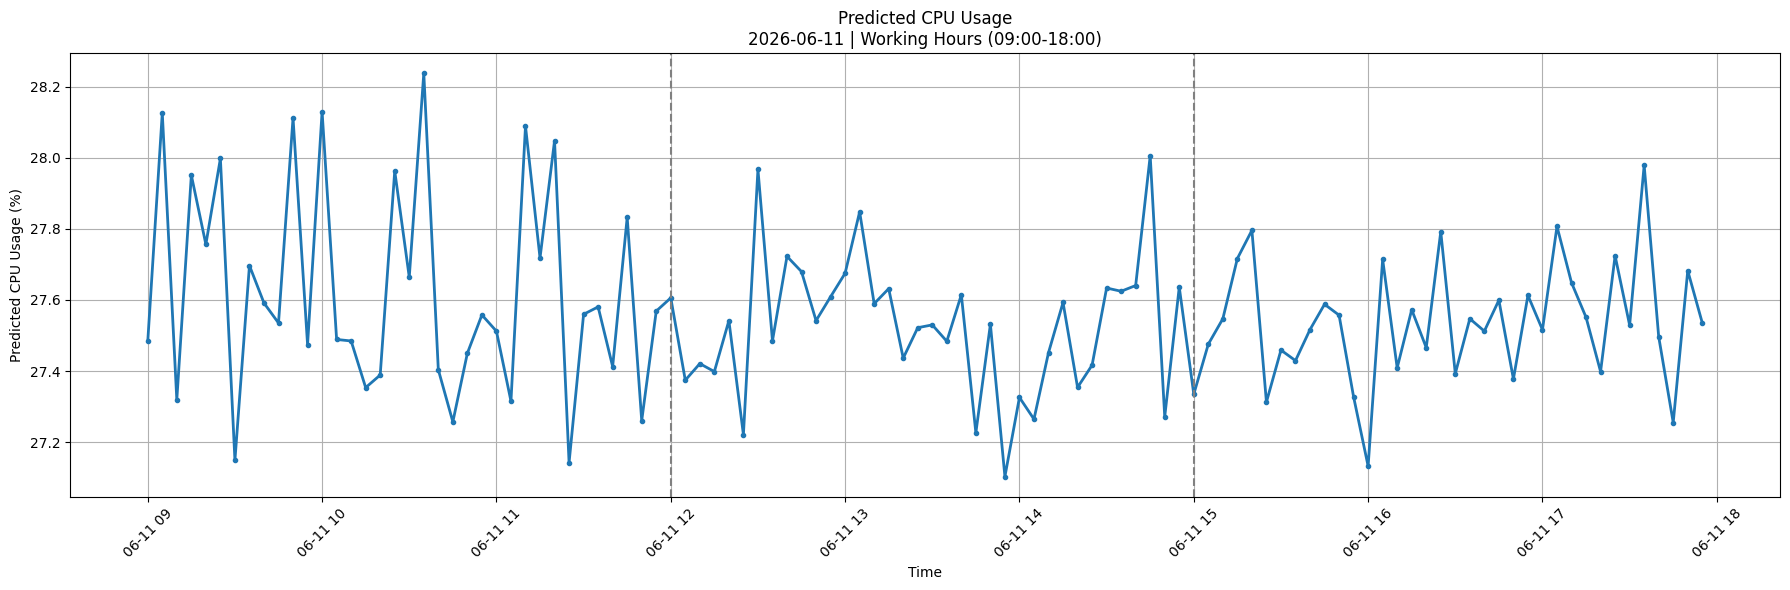

In [27]:
# ==========================================
# Combined Working Hours Prediction
# ==========================================
combined_times = []
combined_values = []
forecast_date = history["ts"].iloc[-108].date()
for block, hour in zip(
    ["09-12","12-15","15-18"],
    [9,12,15]
):
    times = pd.date_range(
        start=pd.Timestamp(
            f"{forecast_date} {hour:02d}:00:00"
        ),
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    combined_times.extend(times)
    combined_values.extend(future_predictions[block])
plt.figure(figsize=(18,6))
plt.plot(
    combined_times,
    combined_values,
    linewidth=2,
    marker='o',
    markersize=3
)
plt.axvline(
    pd.Timestamp(f"{forecast_date} 12:00"),
    color='gray',
    linestyle='--'
)
plt.axvline(
    pd.Timestamp(f"{forecast_date} 15:00"),
    color='gray',
    linestyle='--'
)
plt.title(
    f"Predicted CPU Usage\n{forecast_date} | Working Hours (09:00-18:00)"
)
plt.xlabel("Time")
plt.ylabel("Predicted CPU Usage (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Rows extracted: 108


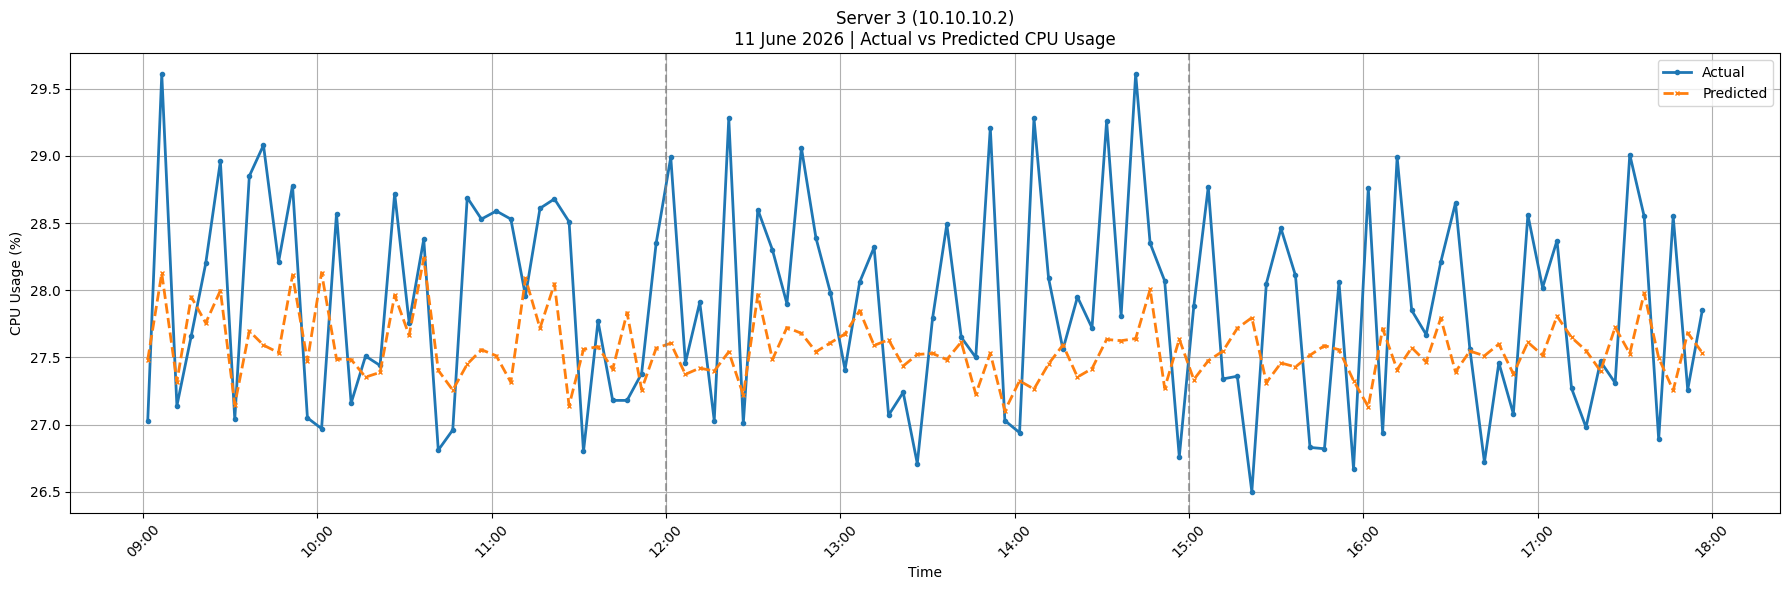

In [28]:
# ==========================================
# Compare 11 June Actual vs Predicted
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ------------------------------------------------
# Load NEW dataset (contains 11 June actual values)
# ------------------------------------------------
future_df = pd.read_csv(r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\test_data_processed\cpu_baseline_new.csv")      # <-- Change filename
future_df["ts"] = pd.to_datetime(future_df["ts"], format="mixed", utc=True)
# ------------------------------------------------
# Select same server
# ------------------------------------------------
future_df = future_df[
    future_df["host_id"] == SERVER_ID
].copy()
future_df = future_df.sort_values("ts")
# ------------------------------------------------
# Extract 11 June Working Hours
# ------------------------------------------------
forecast_date = pd.Timestamp("2026-06-11").date()
actual_df = future_df[
    (future_df["ts"].dt.date == forecast_date) &
    (future_df["ts"].dt.hour >= 9) &
    (future_df["ts"].dt.hour < 18)
].copy()
actual_df = actual_df.reset_index(drop=True)
print("Rows extracted:", len(actual_df))
# Expected: 108 rows
# (9 hours × 12 samples/hour)
# ------------------------------------------------
# Match prediction length
# ------------------------------------------------
n = min(len(actual_df), len(combined_values))
actual_times = actual_df["ts"].iloc[:n]
actual_cpu = actual_df["cpu_usage_pct"].iloc[:n].values
predicted_cpu = np.array(combined_values[:n])
# ------------------------------------------------
# Plot Comparison
# ------------------------------------------------
plt.figure(figsize=(18,6))
plt.plot(
    actual_times,
    actual_cpu,
    linewidth=2,
    marker='o',
    markersize=3,
    label="Actual"
)
plt.plot(
    actual_times,
    predicted_cpu,
    '--',
    linewidth=2,
    marker='x',
    markersize=3,
    label="Predicted"
)
plt.axvline(
    pd.Timestamp("2026-06-11 12:00"),
    color='gray',
    linestyle='--',
    alpha=0.7
)
plt.axvline(
    pd.Timestamp("2026-06-11 15:00"),
    color='gray',
    linestyle='--',
    alpha=0.7
)
plt.title(
    f"Server {SERVER_ID} ({server_df['hostName'].iloc[0]})\n"
    "11 June 2026 | Actual vs Predicted CPU Usage"
)
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.grid(True)
plt.legend()
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_cpu, predicted_cpu)
rmse = np.sqrt(mean_squared_error(actual_cpu, predicted_cpu))
r2 = r2_score(actual_cpu, predicted_cpu)

print("=" * 50)
print("11 June Forecast Performance")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

11 June Forecast Performance
MAE  : 0.6656
RMSE : 0.8210
R²   : -0.1486


In [30]:
# ==========================================
# Deviation Analysis
# ==========================================

deviation_df = pd.DataFrame({
    "Timestamp": actual_times,
    "Actual_CPU": actual_cpu,
    "Predicted_CPU": predicted_cpu
})

# Absolute Error
deviation_df["Absolute_Error"] = (
    deviation_df["Actual_CPU"] -
    deviation_df["Predicted_CPU"]
).abs()

# Signed Error
deviation_df["Signed_Error"] = (
    deviation_df["Actual_CPU"] -
    deviation_df["Predicted_CPU"]
)

# Percentage Error
deviation_df["Percentage_Error"] = (
    deviation_df["Absolute_Error"] /
    deviation_df["Actual_CPU"]
) * 100

# Squared Error
deviation_df["Squared_Error"] = (
    deviation_df["Signed_Error"] ** 2
)

deviation_df.head(10)

,Timestamp,Actual_CPU,Predicted_CPU,Absolute_Error,Signed_Error,Percentage_Error,Squared_Error
0,2026-06-11 09:01:39.658000+00:00,27.03,27.483368,0.453368,-0.453368,1.677277,0.205542
1,2026-06-11 09:06:28.974000+00:00,29.61,28.126148,1.483852,1.483852,5.011320,2.201816
2,2026-06-11 09:11:41.395000+00:00,27.14,27.319048,0.179048,-0.179048,0.659720,0.032058
3,2026-06-11 09:16:37.763000+00:00,27.66,27.951191,0.291191,-0.291191,1.052751,0.084792
4,2026-06-11 09:21:36.751000+00:00,28.20,27.756449,0.443551,0.443551,1.572877,0.196738
5,2026-06-11 09:26:39.322000+00:00,28.96,27.998215,0.961785,0.961785,3.321082,0.925031
6,2026-06-11 09:31:36.482000+00:00,27.04,27.148699,0.108699,-0.108699,0.401993,0.011815
7,2026-06-11 09:36:36.764000+00:00,28.85,27.696753,1.153247,1.153247,3.997392,1.329980
8,2026-06-11 09:41:29.084000+00:00,29.08,27.591394,1.488606,1.488606,5.119001,2.215947
9,2026-06-11 09:46:40.350000+00:00,28.21,27.535112,0.674888,0.674888,2.392370,0.455473


In [31]:
# ==========================================
# Deviation Summary
# ==========================================
print("="*50)
print("Deviation Summary")
print("="*50)
print(f"Mean Absolute Error        : {deviation_df['Absolute_Error'].mean():.3f}")
print(f"Maximum Absolute Error     : {deviation_df['Absolute_Error'].max():.3f}")
print(f"Mean Percentage Error (%)  : {deviation_df['Percentage_Error'].mean():.2f}")
print(f"Maximum Percentage Error (%) : {deviation_df['Percentage_Error'].max():.2f}")
print(f"Standard Deviation of Error : {deviation_df['Signed_Error'].std():.3f}")

Deviation Summary
Mean Absolute Error        : 0.666
Maximum Absolute Error     : 2.016
Mean Percentage Error (%)  : 2.36
Maximum Percentage Error (%) : 6.88
Standard Deviation of Error : 0.752


In [32]:
# ==========================================
# Save Entire Test Set Working-Hour Predictions
# ==========================================
test_predictions = []
test_days = sorted(forecast_df["prediction_day"].unique())
for day in test_days:
    day_df = forecast_df[
        forecast_df["prediction_day"] == day
    ].copy()
    for hour in [9, 12, 15]:
        target = pd.Timestamp(
            f"{day} {hour:02d}:00:00",
            tz="UTC"
        )
        candidates = day_df[
            day_df["forecast_start"] >= target
        ]
        if len(candidates) == 0:
            continue
        row = candidates.iloc[0]
        times = pd.date_range(
            start=row["forecast_start"],
            periods=FORECAST_HORIZON,
            freq="5min"
        )
        for i in range(FORECAST_HORIZON):
            test_predictions.append({
                "host_id": SERVER_ID,
                "hostName": server_df["hostName"].iloc[0],
                "Timestamp": times[i],
                "Actual_CPU_Usage": row[f"Actual_t+{i+1}"],
                "Predicted_CPU_Usage": row[f"Predicted_t+{i+1}"],
                "Forecast_Type": "Test"
            })
test_predictions_df = pd.DataFrame(test_predictions)
print(test_predictions_df.shape)
test_predictions_df.head()

(1836, 6)


,host_id,hostName,Timestamp,Actual_CPU_Usage,Predicted_CPU_Usage,Forecast_Type
0,3,10.10.10.2,2026-05-25 09:00:00+00:00,28.0,28.701757,Test
1,3,10.10.10.2,2026-05-25 09:05:00+00:00,28.0,27.575222,Test
2,3,10.10.10.2,2026-05-25 09:10:00+00:00,28.0,28.566841,Test
3,3,10.10.10.2,2026-05-25 09:15:00+00:00,29.0,27.985332,Test
4,3,10.10.10.2,2026-05-25 09:20:00+00:00,29.0,27.977209,Test


In [33]:
# ==========================================
# Append 11 June Future Prediction
# ==========================================
future_rows = []
for block, hour in zip(
    ["09-12", "12-15", "15-18"],
    [9, 12, 15]
):
    # IMPORTANT: timezone-aware timestamps
    times = pd.date_range(
        start=pd.Timestamp(
            f"{forecast_date} {hour:02d}:00:00",
            tz="UTC"
        ),
        periods=FORECAST_HORIZON,
        freq="5min"
    )
    preds = future_predictions[block]
    for t, p in zip(times, preds):
        future_rows.append({
            "host_id": SERVER_ID,
            "hostName": server_df["hostName"].iloc[0],
            "Timestamp": t,
            "Actual_CPU_Usage": np.nan,
            "Predicted_CPU_Usage": float(p),
            "Forecast_Type": "Future"
        })
future_predictions_df = pd.DataFrame(future_rows)
print(future_predictions_df.shape)
future_predictions_df.head()

(108, 6)


,host_id,hostName,Timestamp,Actual_CPU_Usage,Predicted_CPU_Usage,Forecast_Type
0,3,10.10.10.2,2026-06-11 09:00:00+00:00,NaN,27.483368,Future
1,3,10.10.10.2,2026-06-11 09:05:00+00:00,NaN,28.126148,Future
2,3,10.10.10.2,2026-06-11 09:10:00+00:00,NaN,27.319048,Future
3,3,10.10.10.2,2026-06-11 09:15:00+00:00,NaN,27.951191,Future
4,3,10.10.10.2,2026-06-11 09:20:00+00:00,NaN,27.756449,Future


In [34]:
# ==========================================
# Combine Test + Future Predictions
# ==========================================
prediction_results = pd.concat(
    [
        test_predictions_df,
        future_predictions_df
    ],
    ignore_index=True
)
prediction_results = prediction_results.sort_values(
    "Timestamp"
).reset_index(drop=True)
prediction_results.to_csv(
    f"server_{SERVER_ID}_working_hours_predictions.csv",
    index=False
)
print("=" * 60)
print("Prediction file saved successfully.")
print("=" * 60)
print("Dataset Shape:", prediction_results.shape)
display(prediction_results.head())
display(prediction_results.tail())

Prediction file saved successfully.
Dataset Shape: (1944, 6)


,host_id,hostName,Timestamp,Actual_CPU_Usage,Predicted_CPU_Usage,Forecast_Type
0,3,10.10.10.2,2026-05-25 09:00:00+00:00,28.0,28.701757,Test
1,3,10.10.10.2,2026-05-25 09:05:00+00:00,28.0,27.575222,Test
2,3,10.10.10.2,2026-05-25 09:10:00+00:00,28.0,28.566841,Test
3,3,10.10.10.2,2026-05-25 09:15:00+00:00,29.0,27.985332,Test
4,3,10.10.10.2,2026-05-25 09:20:00+00:00,29.0,27.977209,Test


,host_id,hostName,Timestamp,Actual_CPU_Usage,Predicted_CPU_Usage,Forecast_Type
1939,3,10.10.10.2,2026-06-11 17:35:00+00:00,NaN,27.979033,Future
1940,3,10.10.10.2,2026-06-11 17:40:00+00:00,NaN,27.496605,Future
1941,3,10.10.10.2,2026-06-11 17:45:00+00:00,NaN,27.254936,Future
1942,3,10.10.10.2,2026-06-11 17:50:00+00:00,NaN,27.682430,Future
1943,3,10.10.10.2,2026-06-11 17:55:00+00:00,NaN,27.535450,Future


In [36]:
# ==========================================
# Save Feature Column Names
# ==========================================

import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save feature names in the exact order used for training
FEATURE_COLUMNS = X_train.columns.tolist()

joblib.dump(
    FEATURE_COLUMNS,
    "models/feature_columns.pkl"
)

print("✓ Feature columns saved successfully.")
print(f"Number of features: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)

✓ Feature columns saved successfully.
Number of features: 443
['cpu_lag_1', 'cpu_lag_2', 'cpu_lag_3', 'cpu_lag_4', 'cpu_lag_5', 'cpu_lag_6', 'cpu_lag_7', 'cpu_lag_8', 'cpu_lag_9', 'cpu_lag_10', 'cpu_lag_11', 'cpu_lag_12', 'cpu_lag_13', 'cpu_lag_14', 'cpu_lag_15', 'cpu_lag_16', 'cpu_lag_17', 'cpu_lag_18', 'cpu_lag_19', 'cpu_lag_20', 'cpu_lag_21', 'cpu_lag_22', 'cpu_lag_23', 'cpu_lag_24', 'cpu_lag_25', 'cpu_lag_26', 'cpu_lag_27', 'cpu_lag_28', 'cpu_lag_29', 'cpu_lag_30', 'cpu_lag_31', 'cpu_lag_32', 'cpu_lag_33', 'cpu_lag_34', 'cpu_lag_35', 'cpu_lag_36', 'cpu_lag_37', 'cpu_lag_38', 'cpu_lag_39', 'cpu_lag_40', 'cpu_lag_41', 'cpu_lag_42', 'cpu_lag_43', 'cpu_lag_44', 'cpu_lag_45', 'cpu_lag_46', 'cpu_lag_47', 'cpu_lag_48', 'cpu_lag_49', 'cpu_lag_50', 'cpu_lag_51', 'cpu_lag_52', 'cpu_lag_53', 'cpu_lag_54', 'cpu_lag_55', 'cpu_lag_56', 'cpu_lag_57', 'cpu_lag_58', 'cpu_lag_59', 'cpu_lag_60', 'cpu_lag_61', 'cpu_lag_62', 'cpu_lag_63', 'cpu_lag_64', 'cpu_lag_65', 'cpu_lag_66', 'cpu_lag_67', 'cpu_lag